<a href="https://colab.research.google.com/github/dranphphmithe-ux/Book-Rental-System-Project/blob/main/%E0%B8%A3%E0%B8%A7%E0%B8%A1%E0%B9%82%E0%B8%84%E0%B9%89%E0%B8%94%E0%B8%AA%E0%B9%88%E0%B8%87.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

# ส่วนใหม่

In [2]:
import os
import csv
import io
import ssl
from datetime import date
from urllib.request import Request, urlopen
from datetime import date, datetime
import random
# 1. ดาวน์โหลดฟอนต์ภาษาไทย (TH Sarabun New)
!wget -q https://github.com/Phonbopit/sarabun-webfont/raw/master/fonts/thsarabunnew-webfont.ttf

import matplotlib as mpl
import matplotlib.font_manager as fm
import matplotlib.pyplot as plt

# 2. นำฟอนต์เข้าสู่ระบบของ Matplotlib
fm.fontManager.addfont('thsarabunnew-webfont.ttf')
mpl.rc('font', family='TH Sarabun New', size=14)

# ฟังก์ชันที่ 1: คำนวณวันกำหนดส่ง (มี parameter, มี return)
def calculate_due_date(start_date_str: str, duration_days: int) -> str:
    """คำนวณวันกำหนดส่งคืนจากวันที่เริ่มเช่าและจำนวนวัน"""
    start_date_obj = datetime.strptime(start_date_str, "%Y-%m-%d %H:%M:%S")
    due_date_obj = start_date_obj + timedelta(days=duration_days)
    return due_date_obj.strftime("%Y-%m-%d")


# ฟังก์ชันที่ 2: จัดรูปแบบราคา (มี parameter, มี return)
def format_currency(amount: float) -> str:
    """จัดรูปแบบตัวเลขเป็นข้อความสกุลเงิน บาท"""
    return f"{amount:,.2f} บาท"


# ฟังก์ชันที่ 3: ตรวจสอบระดับลูกค้า (มี default argument, parameter, return)
def get_customer_level(points: int, status: str = "ปกติ") -> str:
    """ตรวจสอบระดับลูกค้าจากแต้มและสถานะ (default status='ปกติ')"""
    if status == "ระงับ":
        return "ไม่มีระดับ (ระงับ)"
    if points >= 500:
        return "Platinum"
    if points >= 200:
        return "Gold"
    if points >= 50:
        return "Silver"
    return "Member"

# ==================================================
# (จากนั้นตามด้วย class Customer ... จนจบโค้ดเดิม)
# ==================================================

#ขอ'กร
# ==================================================
# 1. ระบบจัดการสมาชิก (Customer & CustomerManager)
# ==================================================
class Customer:
    """คลาสสำหรับเก็บข้อมูลสมาชิกหน้าร้าน"""
    def __init__(self,name: str,customer_id: str,phone: str,email: str = "",points: int = 0,register_date: str = None,status: str = "ปกติ",):
        self.name = name
        self.customer_id = customer_id
        self.phone = phone  # เบอร์โทรหลักสำหรับค้นหา
        self.email = email
        self.points = points
        self.register_date = register_date or str(date.today())
        self.status = status

    def add_points(self, amount: int):
        """เพิ่มแต้มเมื่อทำรายการเช่าหน้าร้านสำเร็จ"""
        self.points += amount
        print(
            f"  [ระบบแต้ม] เพิ่มให้คุณ {self.name} +{amount} แต้ม (สะสมรวม:"
            f" {self.points} แต้ม)"
        )

    def update_info(
        self, name: str = None, phone: str = None, email: str = None
    ):
        """พนักงานแก้ไขข้อมูลให้ลูกค้าหน้าร้าน"""
        if name:
            self.name = name
        if phone:
            self.phone = phone
        if email:
            self.email = email
        print(f"  [อัปเดตข้อมูล] แก้ไขข้อมูลของคุณ {self.name} เรียบร้อย")


class CustomerManager:
    """ระบบจัดการสมาชิกหน้าร้านสำหรับพนักงาน"""

    def __init__(self):
        # เก็บข้อมูลโดยใช้ 'เบอร์โทร' เป็น Key เพื่อให้ค้นหาไวที่สุด
        self.customers_db = {}
        self.last_id_number = 0

    def register_customer(self, name: str, phone: str, email: str = ""):
        """พนักงานกดเพิ่มสมาชิกใหม่"""
        # 1. ตรวจสอบเบอร์โทรซ้ำ
        if phone in self.customers_db:
            print(f"❌ ไม่สามารถสมัครได้: เบอร์โทร {phone} เป็นสมาชิกอยู่แล้ว!")
            return self.customers_db[phone]

        # 2. รันรหัสสมาชิกให้อัตโนมัติ (เช่น CUST001, CUST002)
        self.last_id_number += 1
        new_id = f"CUST{self.last_id_number:03d}"

        # 3. สร้าง Object Customer
        new_customer = Customer(
            name=name,
            customer_id=new_id,
            phone=phone,
            email=email,
            points=0,  # สมาชิกใหม่เริ่มที่ 0 แต้ม
        )

        # 4. บันทึกลงระบบ
        self.customers_db[phone] = new_customer
        print(
            f"✅ สมัครสำเร็จ! [รหัส: {new_id} | ชื่อ: {name} | เบอร์: {phone} |"
            f" วันที่: {new_customer.register_date}]"
        )
        return new_customer

    def find_customer_by_phone(self, phone: str):
        """พนักงานค้นหาสมาชิกด้วยเบอร์โทรตอนลูกค้ามาเช่าหนังสือ"""
        customer = self.customers_db.get(phone)
        if customer:
            print(
                f"🔍 พบข้อมูล: คุณ{customer.name} (รหัส: {customer.customer_id}"
                f" | แต้ม: {customer.points})"
            )
            return customer
        else:
            print(f"❌ ไม่พบข้อมูลสมาชิกจากเบอร์โทร: {phone}")
            return None


In [3]:
import csv
import io
import ssl
from urllib.request import Request, urlopen

#ของกวาง
# ==================================================
# 1. Class Book (โครงสร้างข้อมูลหนังสือ)
# ==================================================
class Book:
    """คลาสสำหรับเก็บข้อมูลหนังสือการ์ตูนแต่ละเล่ม"""

    def __init__(
        self,
        book_isbn: str,
        title: str,
        author: str,
        price: str | float,
        category_id: str,
        sub_category_id: str,
        shelf_location: str,
        stock_qty: str | int,
    ):
        self.book_isbn = str(book_isbn).strip()
        self.title = str(title).strip()
        self.author = str(author).strip()

        try:
            self.price = float(price) if price else 0.0
        except ValueError:
            self.price = 0.0

        try:
            self.stock_qty = int(stock_qty) if stock_qty else 0
        except ValueError:
            self.stock_qty = 0

        self.category_id = str(category_id).strip()
        self.sub_category_id = str(sub_category_id).strip()
        self.shelf_location = str(shelf_location).strip()

    @property
    def status(self) -> str:
        """สถานะการเช่า: ถ้าสต็อก > 0 เป็น 'พร้อมเช่า' ถ้าสต็อก <= 0 เป็น 'สินค้าหมด'"""
        return "พร้อมเช่า" if self.stock_qty > 0 else "สินค้าหมด"

    def is_available(self) -> bool:
        return self.stock_qty > 0

    def decrease_stock(self, qty: int = 1) -> bool:
        if self.stock_qty >= qty:
            self.stock_qty -= qty
            return True
        return False

    def increase_stock(self, qty: int = 1):
        self.stock_qty += qty



In [4]:
#ของตุ
# ==================================================
# 2. Class BookCatalogManager (ค้นหาและแสดงผล UI ตาราง)
# ==================================================
class BookCatalogManager:
    """ระบบคลังหนังสือหน้าร้าน พร้อมหน้าจอแสดงผลค้นหาแบบตาราง"""

import csv

# 1.นิยาม Class
class BookSearch:

    def __init__(self, filepath: str):
        self.catalog = []
        self.load_data(filepath)

    def load_data(self, filepath: str):
        try:
            with open(filepath, mode="r", encoding="utf-8-sig") as f:
                reader = csv.DictReader(f)
                self.catalog = [row for row in reader]
            print(
                "ระบบพร้อมใช้งาน: โหลดข้อมูลหนังสือเรียบร้อย"
                f" {len(self.catalog)} รายการ\n"
            )
        except Exception as e:
            print(f"เกิดข้อผิดพลาดในการโหลดไฟล์ CSV: {e}\n")

    def search_by_title(self, keyword: str):
        print(f"ผลการค้นหาชื่อหนังสือ: '{keyword}'")
        results = [
            b
            for b in self.catalog
            if keyword.lower() in b.get("title", "").lower()
        ]
        self._show_results(results)

    def search_by_isbn(self, isbn_code: str):
        print(f"ผลการค้นหารหัส/ISBN: '{isbn_code}'")
        results = [
            b
            for b in self.catalog
            if isbn_code.lower() in b.get("book_isbn", "").lower()
        ]
        self._show_results(results)

    def _show_results(self, results: list):
        if not results:
            print("ไม่พบข้อมูลหนังสือที่คุณต้องการค้นหา\n")
            return

        print(f"พบรายการหนังสือทั้งหมด {len(results)} รายการ")
        print("┌" + "─" * 76 + "┐")

        for i, b in enumerate(results, 1):
            isbn = b.get("book_isbn", "-")
            title = b.get("title", "-")
            author = b.get("author", "-")
            price = b.get("price", "-")
            shelf = b.get("shelf_location", "-")
            stock = b.get("stock_qty", "-")

            print(f"  [{i:02d}] {title}")
            print(
                f"       ISBN: {isbn:<14} ผู้แต่ง: {author:<22} ชั้นวาง:"
                f" {shelf}"
            )
            print(
                f"       ราคา: {price:>5} บาท             จำนวนคงเหลือ:"
                f" {stock} เล่ม"
            )

            if i < len(results):
                print("  " + "┈" * 36)

        print("└" + "─" * 76 + "┘\n")


In [5]:
class Receipt:   #ของน้ำหวาน
    """คลาสคำนวณเงินและออกใบเสร็จ (ปรับโปรโมชั่นเป็น: แถมวันยืมเพิ่มฟรี)"""

    def __init__(
        self,
        order_id: str,
        customer: Customer,
        items: list[Book],
        days_rented: int,
        days_late: int = 0,
        use_points_promo: bool = True,
    ):
        self.order_id = order_id
        self.customer = customer
        self.items = items
        self.days_rented = days_rented
        self.days_late = max(0, days_late)
        self.use_points_promo = use_points_promo
        self.date_issued = datetime.now().strftime("%Y-%m-%d %H:%M:%S")

    def _calculate_rental_fee_by_days(self, days: int) -> float:
        """อัตราค่ายืม: 3 วันแรก 20 บาท, เศษวันถัดไปวันละ 7 บาท"""
        if days <= 0:
            return 0.0
        sets_of_3 = days // 3
        remaining_days = days % 3
        return (sets_of_3 * 20) + (remaining_days * 7)

    def calculate_totals(self) -> dict:
        total_books = len(self.items)

        # 1. เช็กสิทธิ์แถมวันยืมเพิ่ม (ใช้ 10 แต้ม = แถมวันยืมฟรี 1 วัน)
        free_days = 0
        points_used = 0
        if self.use_points_promo and self.customer.points >= 10:
            free_days = 1  # แถมวันยืมฟรี 1 วัน
            points_used = 10

        # 2. คำนวณจำนวนวันที่ต้องนำมาคิดเงินจริง (วันเช่าจริง - วันที่ได้แถม)
        billable_days = max(3, self.days_rented - free_days)

        # 3. คำนวณค่ายืม
        rental_fee_per_book = self._calculate_rental_fee_by_days(
            self.days_rented
        )
        actual_fee_per_book = self._calculate_rental_fee_by_days(billable_days)

        total_rental_before_discount = total_books * rental_fee_per_book
        total_rental_fee = total_books * actual_fee_per_book
        total_discount = total_rental_before_discount - total_rental_fee

        # 4. ค่าปรับคืนช้า (10 บาท/เล่ม/วัน)
        total_fine = total_books * self.days_late * 10
        grand_total = total_rental_fee + total_fine

        # 5. คำนวณแต้มที่จะได้รับเพิ่ม (เช่า 1 เล่ม = 1 แต้ม, คืนตรงเวลา = +1 แต้ม)
        base_points = total_books
        on_time_bonus = 1 if self.days_late == 0 else 0
        earned_points = base_points + on_time_bonus

        return {
            "total_books": total_books,
            "free_days": free_days,
            "points_used": points_used,
            "billable_days": billable_days,
            "total_rental_fee": total_rental_fee,
            "total_discount": total_discount,
            "total_fine": total_fine,
            "grand_total": grand_total,
            "earned_points": earned_points,
        }

    def print_receipt(self):
        calc = self.calculate_totals()

        # ตัดสต็อกหนังสือ
        for book in self.items:
            book.decrease_stock(1)

        # อัปเดตแต้มสมาชิก (แต้มเดิม - แต้มที่ใช้ + แต้มใหม่ที่ได้)
        self.customer.points -= calc["points_used"]
        self.customer.add_points(calc["earned_points"])

        print("=" * 60)
        print(f"{'ใบเสร็จรับเงิน / Receipt':^60}")
        print("=" * 60)
        print(f"เลขที่ใบเสร็จ    : {self.order_id}")
        print(
            f"ชื่อลูกค้า       : คุณ{self.customer.name} (รหัส:"
            f" {self.customer.customer_id})"
        )
        print(
            f"ระยะเวลาเช่า     : {self.days_rented} วัน"
            f" {'(ใช้สิทธิ์แถมฟรี +1 วัน)' if calc['free_days'] > 0 else ''}"
        )
        print("-" * 60)

        print(f"รายการหนังสือที่ยืม ({calc['total_books']} เล่ม):")
        for i, book in enumerate(self.items, 1):
            print(f"  [{i:02d}] {book.title} (ราคาปก {book.price:.0f} บาท)")

        print("-" * 60)
        print(
            "รวมค่ายืมหนังสือ               :"
            f" {calc['total_rental_fee']:.2f} บาท"
        )

        if calc["total_discount"] > 0:
            print(
                "🎁 ส่วนลดสิทธิ์แถมวันยืมเพิ่ม   :-"
                f"{calc['total_discount']:.2f} บาท"
            )

        if calc["total_fine"] > 0:
            print(
                f"❌ ค่าปรับคืนช้า ({self.days_late} วัน x {calc['total_books']} เล่ม"
                f" x 10B) : {calc['total_fine']:.2f} บาท"
            )

        print("-" * 60)
        print(
            f"ยอดชำระสุทธิ (Grand Total)     : {calc['grand_total']:.2f} บาท"
        )
        print("-" * 60)

        if calc["points_used"] > 0:
            print(f"🔄 ใช้แต้มแลกวันยืมเพิ่ม        : -{calc['points_used']} แต้ม")
        print(f"✨ แต้มที่ได้รับครั้งนี้          : +{calc['earned_points']} แต้ม")
        print(f"🏆 แต้มสะสมคงเหลือปัจจุบัน      : {self.customer.points} แต้ม")
        print("=" * 60 + "\n")


In [6]:
import sqlite3

#ของดิว
# ==================================================
# [ส่วนที่นำไปต่อท้าย] ระบบบันทึกข้อมูล SQLite Database
# ==================================================
class DatabaseManager:
    """จัดการฐานข้อมูล SQLite สำหรับบันทึกสมาชิก หนังสือ และใบเสร็จ"""

    def __init__(self, db_name="comic_pos.db"):
        self.db_name = db_name
        self.init_db()

    def get_conn(self):
        return sqlite3.connect(self.db_name)

    def init_db(self):
        """สร้างตารางใน Database หากยังไม่มี"""
        with self.get_conn() as conn:
            cursor = conn.cursor()
            cursor.execute(
                """
                CREATE TABLE IF NOT EXISTS customers (
                    customer_id TEXT PRIMARY KEY, name TEXT, phone TEXT UNIQUE,
                    email TEXT, points INTEGER, register_date TEXT, status TEXT
                )
            """
            )
            cursor.execute(
                """
                CREATE TABLE IF NOT EXISTS books (
                    book_isbn TEXT PRIMARY KEY, title TEXT, author TEXT,
                    price REAL, category_id TEXT, sub_category_id TEXT,
                    shelf_location TEXT, stock_qty INTEGER
                )
            """
            )
            cursor.execute(
                """
                CREATE TABLE IF NOT EXISTS receipts (
                    order_id TEXT PRIMARY KEY, customer_id TEXT, days_rented INTEGER,
                    days_late INTEGER, grand_total REAL, points_used INTEGER,
                    earned_points INTEGER, date_issued TEXT
                )
            """
            )
            cursor.execute(
                """
                CREATE TABLE IF NOT EXISTS receipt_items (
                    order_id TEXT, book_isbn TEXT
                )
            """
            )
            conn.commit()

    def save_customer(self, cust):
        """บันทึก หรือ อัปเดตข้อมูลสมาชิก"""
        with self.get_conn() as conn:
            conn.execute(
                """
                INSERT INTO customers VALUES (?, ?, ?, ?, ?, ?, ?)
                ON CONFLICT(customer_id) DO UPDATE SET
                    name=excluded.name, phone=excluded.phone, email=excluded.email,
                    points=excluded.points, status=excluded.status
            """,
                (
                    cust.customer_id,
                    cust.name,
                    cust.phone,
                    cust.email,
                    cust.points,
                    cust.register_date,
                    cust.status,
                ),
            )
            conn.commit()

    def save_books_from_catalog(self, catalog: list):
        """บันทึกรายการหนังสือทั้งหมดจากคลังลง Database"""
        with self.get_conn() as conn:
            for b in catalog:
                conn.execute(
                    """
                    INSERT INTO books VALUES (?, ?, ?, ?, ?, ?, ?, ?)
                    ON CONFLICT(book_isbn) DO UPDATE SET
                        title=excluded.title, author=excluded.author, price=excluded.price, stock_qty=excluded.stock_qty
                """,
                    (
                        b.book_isbn,
                        b.title,
                        b.author,
                        b.price,
                        b.category_id,
                        b.sub_category_id,
                        b.shelf_location,
                        b.stock_qty,
                    ),
                )
            conn.commit()

    def save_receipt(self, receipt):
        """บันทึกใบเสร็จ อัปเดตแต้มสมาชิก และตัดสต็อกหนังสือใน DB"""
        calc = receipt.calculate_totals()
        with self.get_conn() as conn:
            # 1. บันทึกหัวใบเสร็จ
            conn.execute(
                """
                INSERT INTO receipts VALUES (?, ?, ?, ?, ?, ?, ?, ?)
            """,
                (
                    receipt.order_id,
                    receipt.customer.customer_id,
                    receipt.days_rented,
                    receipt.days_late,
                    calc["grand_total"],
                    calc["points_used"],
                    calc["earned_points"],
                    receipt.date_issued,
                ),
            )

            # 2. บันทึกรายการหนังสือที่ยืม + ตัดสต็อกใน DB
            for item in receipt.items:
                conn.execute(
                    "INSERT INTO receipt_items VALUES (?, ?)",
                    (receipt.order_id, item.book_isbn),
                )
                conn.execute(
                    "UPDATE books SET stock_qty = ? WHERE book_isbn = ?",
                    (item.stock_qty, item.book_isbn),
                )

            # 3. อัปเดตแต้มสมาชิกคงเหลือล่าสุดใน DB
            conn.execute(
                "UPDATE customers SET points = ? WHERE customer_id = ?",
                (receipt.customer.points, receipt.customer.customer_id),
            )
            conn.commit()
        print(f"💾 [DB] บันทึกใบเสร็จเลขที่ {receipt.order_id} ลง Database เรียบร้อย!")


✅ โหลดข้อมูลหนังสือสำเร็จ: 606 รายการ
✅ จำลองข้อมูลและบันทึกลง SQLite ครบ 300 รายการเรียบร้อย!

✅ บันทึกไฟล์จำลองข้อมูลเป็น 'simulated_receipts.csv' เรียบร้อย!



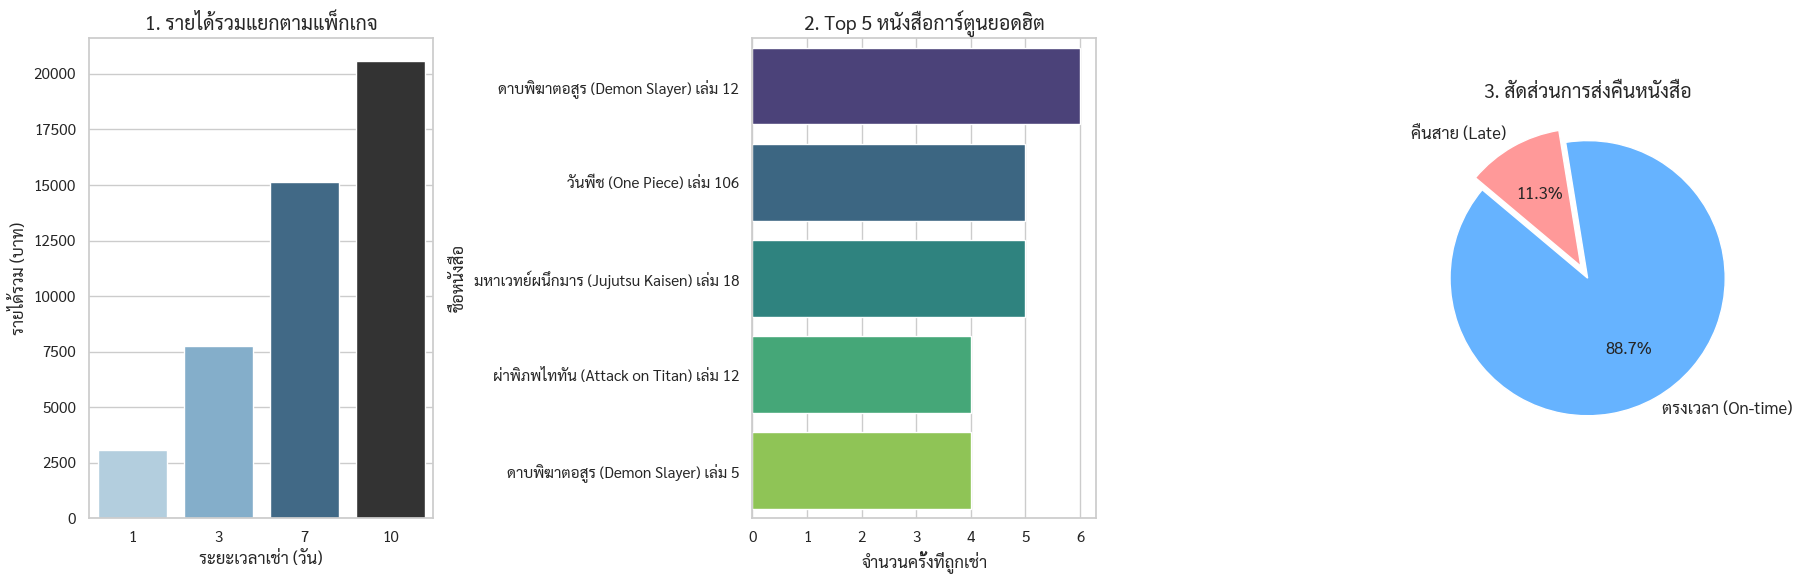

In [8]:
import csv
import os
import random
import sqlite3
import urllib.request
import matplotlib.font_manager as fm
import matplotlib.pyplot as plt
import pandas as pd
import seaborn as sns

# ==========================================
# 0. ดาวน์โหลดและตั้งค่าฟอนต์ภาษาไทยสำหรับ Colab
# ==========================================
font_url = "https://github.com/google/fonts/raw/main/ofl/sarabun/Sarabun-Regular.ttf"
font_path = "Sarabun-Regular.ttf"

if not os.path.exists(font_path):
    urllib.request.urlretrieve(font_url, font_path)

fm.fontManager.addfont(font_path)
plt.rcParams["font.family"] = "Sarabun"
plt.rcParams["axes.unicode_minus"] = False


# ==========================================
# 1. นิยาม Class ที่ระบบต้องใช้งาน
# ==========================================
class Book:

    def __init__(self, data: dict):
        self.book_isbn = data.get("book_isbn", "")
        self.title = data.get("title", "")
        self.author = data.get("author", "")
        self.price = float(data.get("price", 0)) if data.get("price") else 0.0
        self.stock_qty = (
            int(data.get("stock_qty", 0)) if data.get("stock_qty") else 0
        )

    def is_available(self):
        return self.stock_qty > 0


class BookCatalogManager:

    def __init__(self, filepath_or_url: str):
        self.catalog = []
        self.load_data(filepath_or_url)

    def load_data(self, filepath_or_url: str):
        try:
            if filepath_or_url.startswith(
                "http://"
            ) or filepath_or_url.startswith("https://"):
                req = urllib.request.Request(
                    filepath_or_url, headers={"User-Agent": "Mozilla/5.0"}
                )
                with urllib.request.urlopen(req) as response:
                    lines = [
                        line.decode("utf-8-sig") for line in response.readlines()
                    ]
                    reader = csv.DictReader(lines)
                    self.catalog = [Book(row) for row in reader]
            else:
                with open(filepath_or_url, mode="r", encoding="utf-8-sig") as f:
                    reader = csv.DictReader(f)
                    self.catalog = [Book(row) for row in reader]
            print(f"✅ โหลดข้อมูลหนังสือสำเร็จ: {len(self.catalog)} รายการ")
        except Exception as e:
            print(f"❌ เกิดข้อผิดพลาดในการโหลดไฟล์ CSV: {e}")


class Customer:

    def __init__(self, customer_id: int, name: str, phone: str, email: str):
        self.customer_id = customer_id
        self.name = name
        self.phone = phone
        self.email = email


class CustomerManager:

    def __init__(self):
        self.customers = []
        self.counter = 1

    def register_customer(self, name: str, phone: str, email: str):
        c = Customer(self.counter, name, phone, email)
        self.customers.append(c)
        self.counter += 1
        return c

    def find_customer_by_phone(self, phone: str):
        for c in self.customers:
            if c.phone == phone:
                return c
        return None


class Receipt:

    def __init__(
        self,
        order_id: str,
        customer: Customer,
        items: list,
        days_rented: int,
        days_late: int = 0,
    ):
        self.order_id = order_id
        self.customer = customer
        self.items = items
        self.days_rented = days_rented
        self.days_late = days_late

        base_rent = sum(item.price * 0.10 * days_rented for item in items)
        late_fee = len(items) * 15 * days_late
        self.grand_total = round(base_rent + late_fee, 2)


class DatabaseManager:

    def __init__(self, db_path: str):
        self.conn = sqlite3.connect(db_path)
        self._create_tables()

    def _create_tables(self):
        cursor = self.conn.cursor()
        cursor.execute("""
            CREATE TABLE IF NOT EXISTS books (
                book_isbn TEXT PRIMARY KEY,
                title TEXT,
                author TEXT,
                price REAL,
                stock_qty INTEGER
            )
        """)
        cursor.execute("""
            CREATE TABLE IF NOT EXISTS customers (
                customer_id INTEGER PRIMARY KEY,
                name TEXT,
                phone TEXT,
                email TEXT
            )
        """)
        cursor.execute("""
            CREATE TABLE IF NOT EXISTS receipts (
                order_id TEXT PRIMARY KEY,
                customer_id INTEGER,
                days_rented INTEGER,
                days_late INTEGER,
                grand_total REAL
            )
        """)
        cursor.execute("""
            CREATE TABLE IF NOT EXISTS receipt_items (
                order_id TEXT,
                book_isbn TEXT
            )
        """)
        self.conn.commit()

    def save_books_from_catalog(self, catalog):
        cursor = self.conn.cursor()
        for b in catalog:
            cursor.execute(
                "INSERT OR REPLACE INTO books VALUES (?, ?, ?, ?, ?)",
                (b.book_isbn, b.title, b.author, b.price, b.stock_qty),
            )
        self.conn.commit()

    def save_customer(self, c: Customer):
        cursor = self.conn.cursor()
        cursor.execute(
            "INSERT INTO customers VALUES (?, ?, ?, ?)",
            (c.customer_id, c.name, c.phone, c.email),
        )
        self.conn.commit()

    def save_receipt(self, r: Receipt):
        cursor = self.conn.cursor()
        cursor.execute(
            "INSERT INTO receipts VALUES (?, ?, ?, ?, ?)",
            (
                r.order_id,
                r.customer.customer_id,
                r.days_rented,
                r.days_late,
                r.grand_total,
            ),
        )
        for item in r.items:
            cursor.execute(
                "INSERT INTO receipt_items VALUES (?, ?)",
                (r.order_id, item.book_isbn),
            )
        self.conn.commit()

    def get_conn(self):
        return self.conn


# ==========================================
# 2. ฟังก์ชันหลักสำหรับจำลองและวิเคราะห์ข้อมูล
# ==========================================
def run_simulation_and_analysis():
    if os.path.exists("comic_pos.db"):
        os.remove("comic_pos.db")

    db = DatabaseManager("comic_pos.db")
    cust_mgr = CustomerManager()

    csv_url = "https://raw.githubusercontent.com/dranphphmithe-ux/Book-Rental-System-Project/refs/heads/main/books_cleaned.csv"
    catalog_mgr = BookCatalogManager(csv_url)
    db.save_books_from_catalog(catalog_mgr.catalog)

    for i in range(1, 31):
        c = cust_mgr.register_customer(
            name=f"Customer_{i:02d}",
            phone=f"081000{i:04d}",
            email=f"user{i}@email.com",
        )
        db.save_customer(c)

    successful_orders = 0
    order_counter = 1

    while successful_orders < 300:
        random_phone = f"081000{random.randint(1, 30):04d}"
        customer = cust_mgr.find_customer_by_phone(random_phone)

        available_books = [b for b in catalog_mgr.catalog if b.is_available()]

        if not available_books:
            for b in catalog_mgr.catalog:
                b.stock_qty += 10
            available_books = catalog_mgr.catalog

        selected_books = random.sample(
            available_books, k=min(random.randint(1, 4), len(available_books))
        )
        days_rented = random.choice([1, 3, 7, 10])
        days_late = (
            random.choice([0, 0, 0, 1, 2]) if random.random() < 0.25 else 0
        )

        receipt = Receipt(
            order_id=f"REC{order_counter:05d}",
            customer=customer,
            items=selected_books,
            days_rented=days_rented,
            days_late=days_late,
        )

        db.save_receipt(receipt)
        successful_orders += 1
        order_counter += 1

    print(
        "✅ จำลองข้อมูลและบันทึกลง SQLite ครบ"
        f" {successful_orders} รายการเรียบร้อย!\n"
    )

    conn = db.get_conn()

    sql_q1 = pd.read_sql_query(
        """
        SELECT days_rented AS 'ระยะเวลาเช่า (วัน)',
               COUNT(order_id) AS 'จำนวนออเดอร์',
               SUM(grand_total) AS 'รายได้รวม (บาท)'
        FROM receipts
        GROUP BY days_rented
        ORDER BY SUM(grand_total) DESC
    """,
        conn,
    )

    sql_q2 = pd.read_sql_query(
        """
        SELECT b.title AS 'ชื่อหนังสือ',
               COUNT(ri.order_id) AS 'จำนวนครั้งที่ถูกเช่า'
        FROM receipt_items ri
        JOIN books b ON ri.book_isbn = b.book_isbn
        JOIN receipts r ON ri.order_id = r.order_id
        GROUP BY b.book_isbn, b.title
        ORDER BY COUNT(ri.order_id) DESC
        LIMIT 5
    """,
        conn,
    )

    df_receipts = pd.read_sql_query("SELECT * FROM receipts", conn)
    df_receipts.to_csv(
        "simulated_receipts.csv", index=False, encoding="utf-8-sig"
    )
    print("✅ บันทึกไฟล์จำลองข้อมูลเป็น 'simulated_receipts.csv' เรียบร้อย!\n")

    # =================================================================
    # วาดกราฟโดยเปิดใช้งานฟอนต์ Sarabun
    # =================================================================
    sns.set_theme(style="whitegrid", font="Sarabun")

    fig, axes = plt.subplots(1, 3, figsize=(18, 6))

    # กราฟที่ 1
    sns.barplot(
        ax=axes[0],
        data=sql_q1,
        x="ระยะเวลาเช่า (วัน)",
        y="รายได้รวม (บาท)",
        hue="ระยะเวลาเช่า (วัน)",
        palette="Blues_d",
        legend=False,
    )
    axes[0].set_title("1. รายได้รวมแยกตามแพ็กเกจ", fontsize=14, fontweight="bold")

    # กราฟที่ 2
    sns.barplot(
        ax=axes[1],
        data=sql_q2,
        x="จำนวนครั้งที่ถูกเช่า",
        y="ชื่อหนังสือ",
        hue="ชื่อหนังสือ",
        palette="viridis",
        legend=False,
    )
    axes[1].set_title(
        "2. Top 5 หนังสือการ์ตูนยอดฮิต", fontsize=14, fontweight="bold"
    )

    # กราฟที่ 3
    df_receipts["return_status"] = df_receipts["days_late"].apply(
        lambda x: "คืนสาย (Late)" if x > 0 else "ตรงเวลา (On-time)"
    )
    status_counts = df_receipts["return_status"].value_counts()

    axes[2].pie(
        status_counts,
        labels=status_counts.index,
        autopct="%1.1f%%",
        colors=["#66b3ff", "#ff9999"],
        startangle=140,
        explode=(0, 0.1),
        textprops={"fontsize": 12},
    )
    axes[2].set_title(
        "3. สัดส่วนการส่งคืนหนังสือ", fontsize=14, fontweight="bold"
    )

    plt.tight_layout()
    plt.show()


# --- สั่งให้โปรแกรมทำงาน ---
if __name__ == "__main__":
    run_simulation_and_analysis()

✅ โหลดข้อมูลหนังสือสำเร็จ: 606 รายการ
✅ จำลองข้อมูลและบันทึกลง SQLite ครบ 300 รายการเรียบร้อย!

✅ บันทึกไฟล์จำลองข้อมูลเป็น 'simulated_receipts.csv' เรียบร้อย!



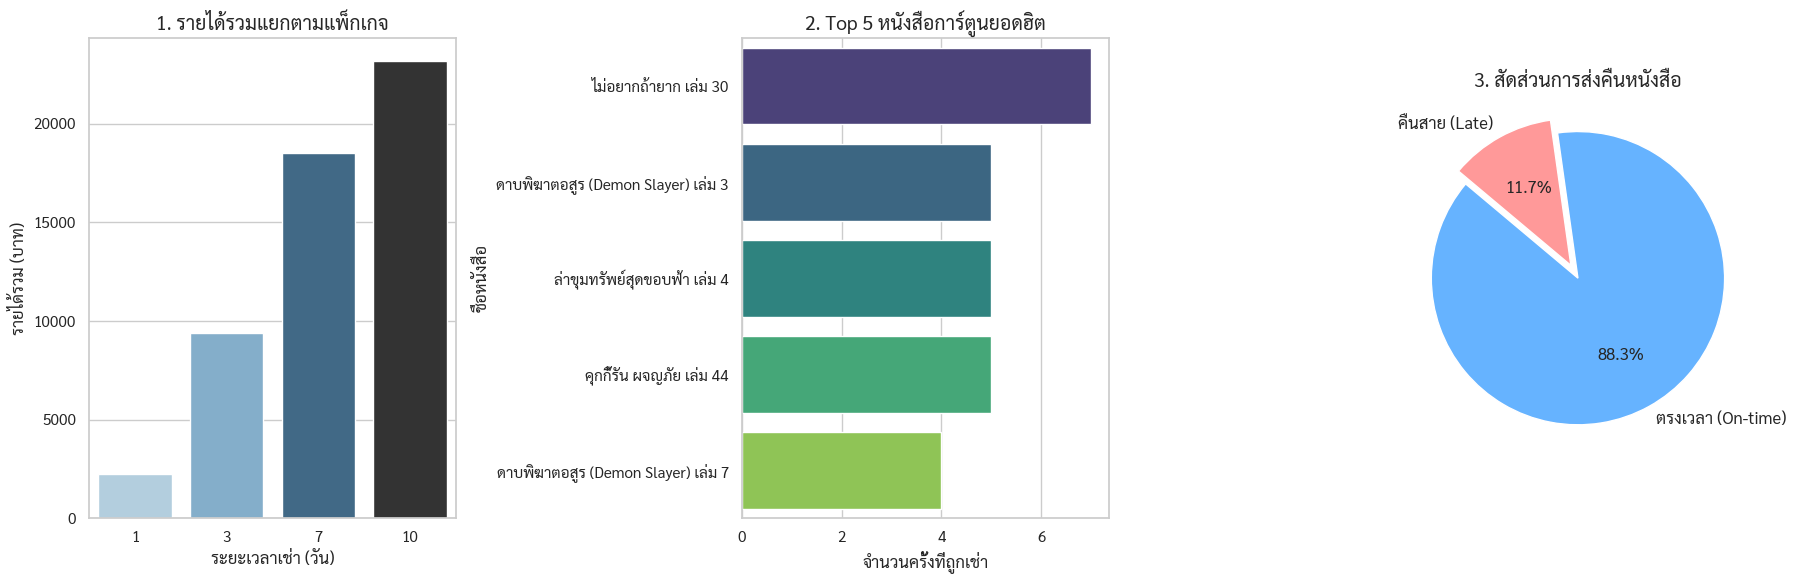

In [11]:
import csv
import os
import random
import sqlite3
import urllib.request
import matplotlib.font_manager as fm
import matplotlib.pyplot as plt
import pandas as pd
import seaborn as sns

# ==========================================
# 0. ดาวน์โหลดและตั้งค่าฟอนต์ภาษาไทยสำหรับ Colab
# ==========================================
font_url = "https://github.com/google/fonts/raw/main/ofl/sarabun/Sarabun-Regular.ttf"
font_path = "Sarabun-Regular.ttf"

if not os.path.exists(font_path):
    urllib.request.urlretrieve(font_url, font_path)

fm.fontManager.addfont(font_path)
plt.rcParams["font.family"] = "Sarabun"
plt.rcParams["axes.unicode_minus"] = False


# ==========================================
# 1. นิยาม Class ที่ระบบต้องใช้งาน (แก้ไขรองรับ points แล้ว)
# ==========================================
class Book:

    def __init__(self, data_or_isbn, title="", price=0, stock_qty=0):
        # รองรับทั้งแบบ passing dict หรือ passing พารามิเตอร์แยก (e.g. Book("B01", "วันพีช", 50, 5))
        if isinstance(data_or_isbn, dict):
            data = data_or_isbn
            self.book_isbn = data.get("book_isbn", "")
            self.title = data.get("title", "")
            self.author = data.get("author", "")
            self.price = (
                float(data.get("price", 0)) if data.get("price") else 0.0
            )
            self.stock_qty = (
                int(data.get("stock_qty", 0)) if data.get("stock_qty") else 0
            )
        else:
            self.book_isbn = data_or_isbn
            self.title = title
            self.author = ""
            self.price = float(price)
            self.stock_qty = int(stock_qty)

    def is_available(self):
        return self.stock_qty > 0


class Customer:
    # แก้ไขเพิ่มพารามิเตอร์ points ให้รองรับ keyword argument 'points'
    def __init__(
        self,
        customer_id: str,
        name: str,
        phone: str = "",
        email: str = "",
        points: int = 0,
    ):
        self.customer_id = customer_id
        self.name = name
        self.phone = phone
        self.email = email
        self.points = points

    def get_tier(self):
        if self.points >= 200:
            return "Gold"
        elif self.points >= 100:
            return "Silver"
        else:
            return "General"


class BookCatalogManager:

    def __init__(self, filepath_or_url: str):
        self.catalog = []
        self.load_data(filepath_or_url)

    def load_data(self, filepath_or_url: str):
        try:
            if filepath_or_url.startswith(
                "http://"
            ) or filepath_or_url.startswith("https://"):
                req = urllib.request.Request(
                    filepath_or_url, headers={"User-Agent": "Mozilla/5.0"}
                )
                with urllib.request.urlopen(req) as response:
                    lines = [
                        line.decode("utf-8-sig") for line in response.readlines()
                    ]
                    reader = csv.DictReader(lines)
                    self.catalog = [Book(row) for row in reader]
            else:
                with open(filepath_or_url, mode="r", encoding="utf-8-sig") as f:
                    reader = csv.DictReader(f)
                    self.catalog = [Book(row) for row in reader]
            print(f"✅ โหลดข้อมูลหนังสือสำเร็จ: {len(self.catalog)} รายการ")
        except Exception as e:
            print(f"❌ เกิดข้อผิดพลาดในการโหลดไฟล์ CSV: {e}")


class CustomerManager:

    def __init__(self):
        self.customers = []
        self.counter = 1

    def register_customer(self, name: str, phone: str, email: str, points: int = 0):
        c = Customer(
            f"C{self.counter:03d}",
            name,
            phone=phone,
            email=email,
            points=points,
        )
        self.customers.append(c)
        self.counter += 1
        return c

    def find_customer_by_phone(self, phone: str):
        for c in self.customers:
            if c.phone == phone:
                return c
        return None


class Receipt:

    def __init__(
        self,
        order_id: str,
        customer: Customer,
        items: list,
        days_rented: int,
        days_late: int = 0,
    ):
        self.order_id = order_id
        self.customer = customer
        self.items = items
        self.days_rented = days_rented
        self.days_late = days_late

        base_rent = sum(item.price * 0.10 * days_rented for item in items)
        late_fee = len(items) * 15 * days_late
        self.grand_total = round(base_rent + late_fee, 2)


class DatabaseManager:

    def __init__(self, db_path: str):
        self.conn = sqlite3.connect(db_path)
        self._create_tables()

    def _create_tables(self):
        cursor = self.conn.cursor()
        cursor.execute("""
            CREATE TABLE IF NOT EXISTS books (
                book_isbn TEXT PRIMARY KEY,
                title TEXT,
                author TEXT,
                price REAL,
                stock_qty INTEGER
            )
        """)
        cursor.execute("""
            CREATE TABLE IF NOT EXISTS customers (
                customer_id TEXT PRIMARY KEY,
                name TEXT,
                phone TEXT,
                email TEXT,
                points INTEGER
            )
        """)
        cursor.execute("""
            CREATE TABLE IF NOT EXISTS receipts (
                order_id TEXT PRIMARY KEY,
                customer_id TEXT,
                days_rented INTEGER,
                days_late INTEGER,
                grand_total REAL
            )
        """)
        cursor.execute("""
            CREATE TABLE IF NOT EXISTS receipt_items (
                order_id TEXT,
                book_isbn TEXT
            )
        """)
        self.conn.commit()

    def save_books_from_catalog(self, catalog):
        cursor = self.conn.cursor()
        for b in catalog:
            cursor.execute(
                "INSERT OR REPLACE INTO books VALUES (?, ?, ?, ?, ?)",
                (b.book_isbn, b.title, b.author, b.price, b.stock_qty),
            )
        self.conn.commit()

    def save_customer(self, c: Customer):
        cursor = self.conn.cursor()
        cursor.execute(
            "INSERT OR REPLACE INTO customers VALUES (?, ?, ?, ?, ?)",
            (c.customer_id, c.name, c.phone, c.email, c.points),
        )
        self.conn.commit()

    def save_receipt(self, r: Receipt):
        cursor = self.conn.cursor()
        cursor.execute(
            "INSERT INTO receipts VALUES (?, ?, ?, ?, ?)",
            (
                r.order_id,
                r.customer.customer_id,
                r.days_rented,
                r.days_late,
                r.grand_total,
            ),
        )
        for item in r.items:
            cursor.execute(
                "INSERT INTO receipt_items VALUES (?, ?)",
                (r.order_id, item.book_isbn),
            )
        self.conn.commit()

    def get_conn(self):
        return self.conn


# ==========================================
# 2. ฟังก์ชันหลักสำหรับจำลองและวิเคราะห์ข้อมูล
# ==========================================
def run_simulation_and_analysis():
    if os.path.exists("comic_pos.db"):
        os.remove("comic_pos.db")

    db = DatabaseManager("comic_pos.db")
    cust_mgr = CustomerManager()

    csv_url = "https://raw.githubusercontent.com/dranphphmithe-ux/Book-Rental-System-Project/refs/heads/main/books_cleaned.csv"
    catalog_mgr = BookCatalogManager(csv_url)
    db.save_books_from_catalog(catalog_mgr.catalog)

    # สร้างข้อมูลลูกค้าจำลอง 30 คน
    for i in range(1, 31):
        c = cust_mgr.register_customer(
            name=f"Customer_{i:02d}",
            phone=f"081000{i:04d}",
            email=f"user{i}@email.com",
            points=random.randint(50, 250),
        )
        db.save_customer(c)

    successful_orders = 0
    order_counter = 1

    while successful_orders < 300:
        random_phone = f"081000{random.randint(1, 30):04d}"
        customer = cust_mgr.find_customer_by_phone(random_phone)

        available_books = [b for b in catalog_mgr.catalog if b.is_available()]

        if not available_books:
            for b in catalog_mgr.catalog:
                b.stock_qty += 10
            available_books = catalog_mgr.catalog

        selected_books = random.sample(
            available_books, k=min(random.randint(1, 4), len(available_books))
        )
        days_rented = random.choice([1, 3, 7, 10])
        days_late = (
            random.choice([0, 0, 0, 1, 2]) if random.random() < 0.25 else 0
        )

        receipt = Receipt(
            order_id=f"REC{order_counter:05d}",
            customer=customer,
            items=selected_books,
            days_rented=days_rented,
            days_late=days_late,
        )

        db.save_receipt(receipt)
        successful_orders += 1
        order_counter += 1

    print(
        "✅ จำลองข้อมูลและบันทึกลง SQLite ครบ"
        f" {successful_orders} รายการเรียบร้อย!\n"
    )

    conn = db.get_conn()

    sql_q1 = pd.read_sql_query(
        """
        SELECT days_rented AS 'ระยะเวลาเช่า (วัน)',
               COUNT(order_id) AS 'จำนวนออเดอร์',
               SUM(grand_total) AS 'รายได้รวม (บาท)'
        FROM receipts
        GROUP BY days_rented
        ORDER BY SUM(grand_total) DESC
    """,
        conn,
    )

    sql_q2 = pd.read_sql_query(
        """
        SELECT b.title AS 'ชื่อหนังสือ',
               COUNT(ri.order_id) AS 'จำนวนครั้งที่ถูกเช่า'
        FROM receipt_items ri
        JOIN books b ON ri.book_isbn = b.book_isbn
        JOIN receipts r ON ri.order_id = r.order_id
        GROUP BY b.book_isbn, b.title
        ORDER BY COUNT(ri.order_id) DESC
        LIMIT 5
    """,
        conn,
    )

    df_receipts = pd.read_sql_query("SELECT * FROM receipts", conn)
    df_receipts.to_csv(
        "simulated_receipts.csv", index=False, encoding="utf-8-sig"
    )
    print("✅ บันทึกไฟล์จำลองข้อมูลเป็น 'simulated_receipts.csv' เรียบร้อย!\n")

    # =================================================================
    # Plotting Graphs with Thai Font Support
    # =================================================================
    sns.set_theme(style="whitegrid", font="Sarabun")

    fig, axes = plt.subplots(1, 3, figsize=(18, 6))

    # Graph 1
    sns.barplot(
        ax=axes[0],
        data=sql_q1,
        x="ระยะเวลาเช่า (วัน)",
        y="รายได้รวม (บาท)",
        hue="ระยะเวลาเช่า (วัน)",
        palette="Blues_d",
        legend=False,
    )
    axes[0].set_title("1. รายได้รวมแยกตามแพ็กเกจ", fontsize=14, fontweight="bold")

    # Graph 2
    sns.barplot(
        ax=axes[1],
        data=sql_q2,
        x="จำนวนครั้งที่ถูกเช่า",
        y="ชื่อหนังสือ",
        hue="ชื่อหนังสือ",
        palette="viridis",
        legend=False,
    )
    axes[1].set_title(
        "2. Top 5 หนังสือการ์ตูนยอดฮิต", fontsize=14, fontweight="bold"
    )

    # Graph 3
    df_receipts["return_status"] = df_receipts["days_late"].apply(
        lambda x: "คืนสาย (Late)" if x > 0 else "ตรงเวลา (On-time)"
    )
    status_counts = df_receipts["return_status"].value_counts()

    axes[2].pie(
        status_counts,
        labels=status_counts.index,
        autopct="%1.1f%%",
        colors=["#66b3ff", "#ff9999"],
        startangle=140,
        explode=(0, 0.1),
        textprops={"fontsize": 12},
    )
    axes[2].set_title(
        "3. สัดส่วนการส่งคืนหนังสือ", fontsize=14, fontweight="bold"
    )

    plt.tight_layout()
    plt.show()


# --- สั่งรันโปรแกรม ---
if __name__ == "__main__":
    run_simulation_and_analysis()